In [1]:
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import platform

In [2]:
if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font',family = 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 데이터 수집 (openapi)
url = 'https://api.thingspeak.com/channels/12397/feeds.json?results=500'
res = requests.get(url)
data = res.json()
data

{'channel': {'id': 12397,
  'name': 'WeatherStation',
  'description': 'MathWorks Weather Station, West Garage, Natick, MA 01760, USA',
  'latitude': '42.299676',
  'longitude': '-71.350525',
  'field1': 'Wind Direction (North = 0 degrees)',
  'field2': 'Wind Speed (mph)',
  'field3': '% Humidity',
  'field4': 'Temperature (F)',
  'field5': 'Rain (Inches/minute)',
  'field6': 'Pressure ("Hg)',
  'field7': 'Power Level (V)',
  'field8': 'Light Intensity',
  'created_at': '2014-05-20T21:50:32Z',
  'updated_at': '2025-10-02T21:56:57Z',
  'elevation': '60',
  'last_entry_id': 5605866},
 'feeds': [{'created_at': '2026-05-26T17:56:38Z',
   'entry_id': 5605367,
   'field1': '172',
   'field2': '3.9',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.8',
   'field7': '0',
   'field8': '0'},
  {'created_at': '2026-05-26T17:57:38Z',
   'entry_id': 5605368,
   'field1': '161',
   'field2': '3.2',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.8',
 

- field1 : 풍향 -> 도 단위(0 ~ 360)
- field2 : 풍속 -> m/s
- field3 : 상대 습도 -> %
- field4 : 기온 -> 화씨 단위
- field5 : 강우량 -> mm
- field6 : 기압 -> hPa
- field7 : 조도/일사량 -> 빛의 세기
- field8 : 센서 배터리의 전압 -> 장비 전원 상태 (V)

In [4]:
df = pd.DataFrame(data['feeds'])
df.head(10)

,created_at,entry_id,field1,field2,field3,field4,field5,field6,field7,field8
0,2026-05-26T17:56:38Z,5605367,172,3.9,0,0.1,0,29.8,0,0
1,2026-05-26T17:57:38Z,5605368,161,3.2,0,0.1,0,29.8,0,0
2,2026-05-26T17:58:38Z,5605369,175,6.7,0,0.1,0,29.81,0,0
3,2026-05-26T17:59:38Z,5605370,119,3.1,0,0.1,0,29.81,0,0
4,2026-05-26T18:01:38Z,5605371,173,3.4,0,0.1,0,29.8,0,0
5,2026-05-26T18:02:38Z,5605372,147,1.2,0,0.1,0,29.8,0,0
6,2026-05-26T18:03:38Z,5605373,148,3.8,0,0.1,0,29.8,0,0
7,2026-05-26T18:05:38Z,5605374,183,2.1,0,0.1,0,29.8,0,0
8,2026-05-26T18:06:38Z,5605375,169,4.6,0,0.1,0,29.8,0,0
9,2026-05-26T18:07:38Z,5605376,124,7.6,0,0.1,0,29.8,0,0


In [5]:
df = df[['created_at','field2']]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   created_at  500 non-null    str  
 1   field2      500 non-null    str  
dtypes: str(2)
memory usage: 7.9 KB


In [6]:
df.columns = ['Time','Value']
df

,Time,Value
0,2026-05-26T17:56:38Z,3.9
1,2026-05-26T17:57:38Z,3.2
2,2026-05-26T17:58:38Z,6.7
3,2026-05-26T17:59:38Z,3.1
4,2026-05-26T18:01:38Z,3.4
...,...,...
495,2026-05-27T03:34:38Z,4.4
496,2026-05-27T03:35:38Z,3.6
497,2026-05-27T03:36:38Z,4.2
498,2026-05-27T03:37:38Z,3.4


In [7]:
df.describe()

,Time,Value
count,500,500
unique,500,78
top,2026-05-26T17:56:38Z,6.2
freq,1,17


In [8]:
df['Value'] = pd.to_numeric(df['Value'])

In [9]:
df.describe()

,Value
count,500.000000
mean,5.462800
std,1.562786
min,1.200000
25%,4.300000
50%,5.350000
75%,6.300000
max,11.900000


In [10]:
# 정규화 -> 스케일링
scaler = MinMaxScaler()
df['scaled_value'] = scaler.fit_transform(df[['Value']])
df.head()

,Time,Value,scaled_value
0,2026-05-26T17:56:38Z,3.9,0.252336
1,2026-05-26T17:57:38Z,3.2,0.186916
2,2026-05-26T17:58:38Z,6.7,0.514019
3,2026-05-26T17:59:38Z,3.1,0.177570
4,2026-05-26T18:01:38Z,3.4,0.205607


In [11]:
features = df[['scaled_value']].values
features

array([[0.25233645],
       [0.18691589],
       [0.51401869],
       [0.17757009],
       [0.20560748],
       [0.        ],
       [0.24299065],
       [0.08411215],
       [0.31775701],
       [0.59813084],
       [0.39252336],
       [0.46728972],
       [0.41121495],
       [0.10280374],
       [0.37383178],
       [0.25233645],
       [0.62616822],
       [0.48598131],
       [0.48598131],
       [0.42056075],
       [0.4953271 ],
       [0.46728972],
       [0.30841121],
       [0.28037383],
       [0.58878505],
       [0.3364486 ],
       [0.47663551],
       [0.36448598],
       [0.42990654],
       [0.44859813],
       [0.3271028 ],
       [0.3364486 ],
       [0.42056075],
       [0.28037383],
       [0.28037383],
       [0.13084112],
       [0.46728972],
       [0.65420561],
       [0.11214953],
       [0.18691589],
       [0.24299065],
       [0.36448598],
       [0.57009346],
       [0.71962617],
       [0.48598131],
       [0.78504673],
       [0.59813084],
       [0.252

In [12]:
class windowDS():
    def __init__(self, _x, _window):
        self.data = _x
        self.window = _window
        self.n = len(_x) - _window
    def __len__(self):
        return self.n
    def __getitem__(self, idx):
        x  = self.data[idx : idx+self.window]
        y = self.data[idx + self.window]
        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.tensor(y).float()
        return x_tensor, y_tensor

In [13]:
sensor_ds = windowDS(features, 10)

train_dl = DataLoader(sensor_ds, batch_size=32, shuffle=False)

In [14]:
class SensorLSTM(nn.Module):
    def __init__(
            self,
            input_size,
            hidden_size
    ):
        super(SensorLSTM,self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first = True
        )
        self.model = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        pred = self.model(h_n[-1])
        return pred

In [15]:
model = SensorLSTM(1, 16)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [16]:
model.train()
for epoch in range(30):
    total_loss = 0.0
    total_n = 0
    for x,y in train_dl:
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    train_loss = total_loss /max(total_n,1)

    if (epoch+1) % 5 == 0:
        print(f'Epoch : {epoch+1}, MSE : {train_loss}')
        

C:\Users\lovek\AppData\Local\Temp\ipykernel_53824\3577485011.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  x_tensor = torch.from_numpy(x).float()


Epoch : 5, MSE : 0.01998092374023126
Epoch : 10, MSE : 0.018848552372382612
Epoch : 15, MSE : 0.017925380318596654
Epoch : 20, MSE : 0.017585204990238558
Epoch : 25, MSE : 0.01745164433912355
Epoch : 30, MSE : 0.01737008166442416


In [32]:
# 예측값 -> 기존의 데이터를 이용해서 예측(원본의 데이터 모두를 예측)
model.eval()

full_loader = DataLoader(sensor_ds, batch_size = len(sensor_ds), shuffle=False)
# for x, y in full_loader:
#     pass
# next(iter(DataLoader)) : 생성된 데이터들중 첫번째 데이터셋을 로드한다
x, y = next(iter(full_loader))

with torch.no_grad():
    pred = model(x)
    errors = torch.abs(y - pred).numpy()

# 오차의 분포에서 상위 5% 지점을 이상치 임계값 설정
threshold = np.percentile(errors, 90)
anomalies = errors > threshold

In [33]:
anomalies

array([[False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [

In [34]:
print('임계 지점의 값 : ', round(threshold, 4))

임계 지점의 값 :  0.2158


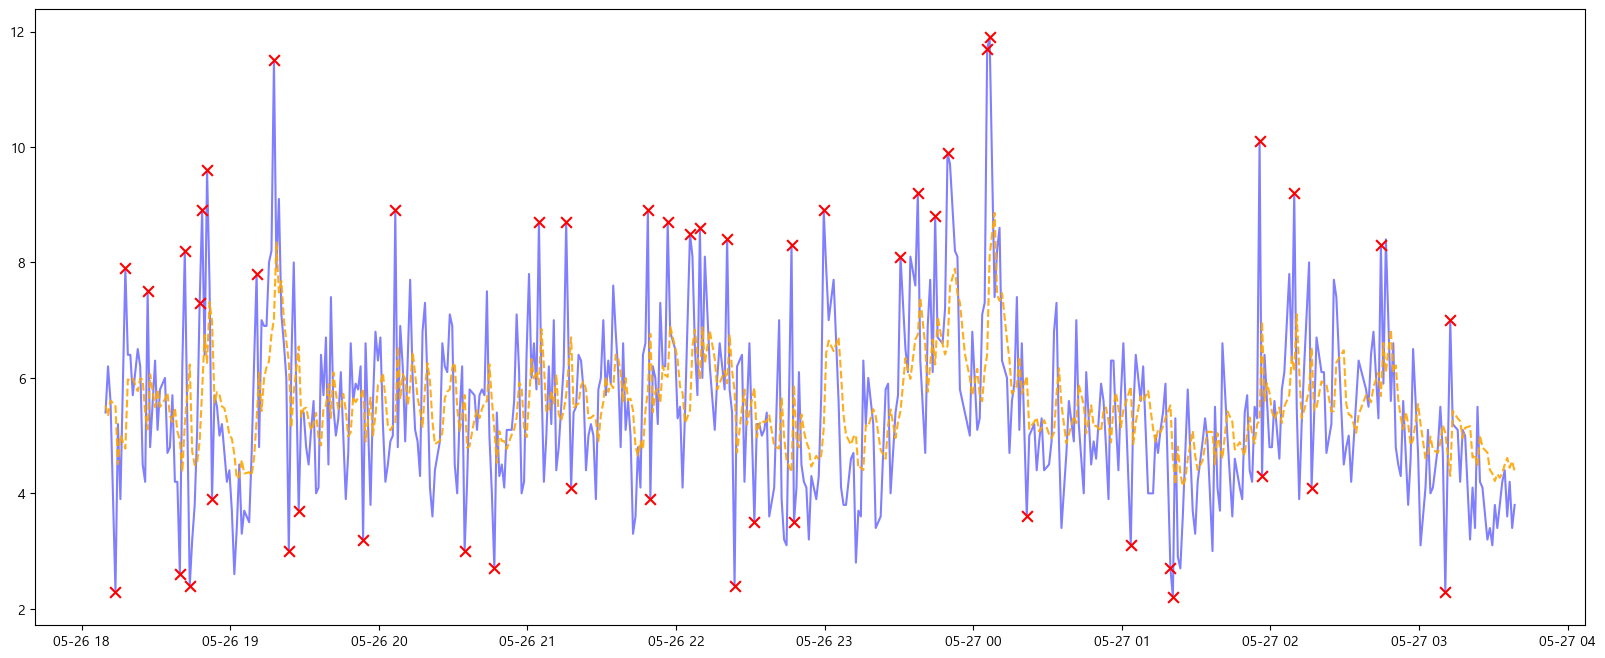

In [35]:
true_y = scaler.inverse_transform(y)
pred_y = scaler.inverse_transform(pred)
df['Time'] = pd.to_datetime(df['Time'])
plot_x = df['Time'].iloc[10:].values

plt.figure(figsize=(20, 8))

plt.plot(plot_x, true_y, label = '실제 센서 데이터', color = 'blue', alpha = 0.5)
plt.plot(plot_x, pred_y, label = '예측 센서 데이터', color = 'orange', alpha = 0.9, linestyle = '--')

# 이상치가 감지된 인덱스를 추출하고 산점도 그래프를 추가하여 이상치를 표시
anomaly_idx = np.where(anomalies)[0]
if len(anomaly_idx) > 0:
    plt.scatter(
        plot_x[anomaly_idx], true_y[anomaly_idx],
        color = 'red', label = '이상 징후 감지',
        s = 60, marker = 'x', zorder=5
    )

plt.show()
